## DynBet QuickStart

DynBet 是一个**动态下注模拟框架**

只需定义游戏 (Game) 输赢规则并组合策略 (Strategy) 

框架维护余额 (Vault) 与对局历史 (Session)

### 1. 定义游戏

SimpleGame 是一个简单的实现, 从列表轮询获取结果, True 表示赢, False 表示输

In [30]:
from game import Game


class SimpleGame(Game):
    def __init__(self, seq: list[bool]):
        self.seq = seq
        self.index = 0

    def once(self, bet: float) -> float | None:
        won = self.seq[self.index % len(self.seq)]
        self.index += 1
        if won:
            # 赢了,双倍返还
            return bet * 2
        # 输了, 啥也没有 (None)


game = SimpleGame([True])  # 一直赢

### 2. 进行游戏

`Vault` 持有余额与初始下注额

`Session` 管理游戏与余额, 每 `run` 一次就进行一局

In [31]:
from session import Session
from vault import Vault
from strategy import Strategy

vault = Vault(1000.0, 10.0)  # 初始余额为 1000, 每局游戏初始下注 10
session = Session(game, vault)  # 创建会话
print(vault.money)  # 1000.0
session.run(Strategy())  # 以空策略运行一次
print(vault.money)  # 1010.0

1000.0
1010.0


### 3. 游戏策略

策略是一个管道: `Strategy().apply(A).apply(B)` 会依次执行 A 和 B

下面的 `Echo` 是我们调试用的妙妙工具, 它包裹任意策略并把**实际下注额**打印出来, 方便观察

In [32]:
from data import Data


class Echo(Strategy):
    def __init__(self, strategy: Strategy, f: str = "-> %.2f\n"):
        super().__init__()
        self.strategy = strategy
        self.format = f

    def apply(self, strategy: Strategy) -> Strategy:
        self.strategy.apply(strategy)
        return self

    def bet(self, vault: Vault, data: Data) -> Vault:
        bet = self.strategy.bet(vault, data)
        print(self.format % bet.withdrawal, end="")
        return bet

#### 3.1 基础策略

最朴素的几种策略: 平注、按比例、全仓、随机

In [33]:
from strategy import Flat

# 平注
session.run(Echo(Flat(20.0)))  # 下注 20 (覆盖初始下注)
print(vault.money)  # 1030.0

-> 20.00
1030.0


In [34]:
from strategy import Ratio

# 按比例下注
session.run(Echo(Ratio(0.5)))  # 下注初始下注的 50%
print(vault.money)  # 1035.0

-> 5.00
1035.0


In [35]:
from strategy import Allin

# 全仓下注
session.run(Echo(Allin()))  # 下注所有资金
print(vault.money)  # 2070.0

-> 1035.00
2070.0


In [36]:
from strategy import Random

# 在余额范围内随机下注
previous = vault.money
bet = session.run(Echo(Random()))
print(vault.money)

vault.money = 1000.0  # 重置余额

-> 789.95
2859.951923068531


#### 3.2 组合策略

用 `apply` 把多个策略串成管道

前面的策略修改下注额, 后面的策略在它的基础上继续作用

In [37]:
strategy = Strategy()  # 创建空策略
strategy.apply(Echo(Flat(100.0)))  # 平注 100
strategy.apply(Echo(Ratio(0.5)))  # 缩放 50%
session.run(strategy)
print(vault.money)  # 1050.0

-> 100.00
-> 50.00
1050.0


错误用法: 所有基础策略都不会执行 apply 在它之上的策略

In [38]:
session.run(Echo(Flat(100.0)).apply(Echo(Ratio(0.5))))  # 下注额 100 不会变成 50
print(vault.money)  # 1150.0

-> 100.00
1150.0


通过组合策略, 可以实现许多复杂的策略

例如下注余额的 10%

In [39]:
strategy = Strategy().apply(Echo(Allin())).apply(Echo(Ratio(0.1)))
session.run(strategy)
print(vault.money)  # 1265.0

-> 1150.00
-> 115.00
1265.0


#### 3.3 分支聚合策略

`Aggregator` (`Max`, `Min`, `Sum`) 会**同时**跑管道里的所有子策略, 再按规则聚合

子策略各自拿到余额快照, 互不影响

In [40]:
from strategy import Max, Min, Sum


def apply(target: Strategy):
    # 应用三个平注子策略
    target.apply(Echo(Flat(10.0), "Sub 1 -> %.2f\n"))
    target.apply(Echo(Flat(20.0), "Sub 2 -> %.2f\n"))
    target.apply(Echo(Flat(30.0), "Sub 3 -> %.2f\n"))
    return target

取最大下注额

In [41]:
strategy = apply(Echo(Max(), "Max -> %.2f\n"))  #
session.run(strategy)
print(vault.money)  # 1295.0

Sub 1 -> 10.00
Sub 2 -> 20.00
Sub 3 -> 30.00
Max -> 30.00
1295.0


取最小下注额

In [42]:
strategy = apply(Echo(Min(), "Min -> %.2f\n"))
session.run(strategy)
print(vault.money)  # 1305.0

Sub 1 -> 10.00
Sub 2 -> 20.00
Sub 3 -> 30.00
Min -> 10.00
1305.0


Sum -> Ratio 取平均下注额

In [43]:
strategy = Strategy().apply(apply(Sum())).apply(Ratio(1 / 3))
strategy = Echo(strategy, "Average -> %.2f\n")
session.run(strategy)
print(vault.money)  # 1325.0

Sub 1 -> 10.00
Sub 2 -> 20.00
Sub 3 -> 30.00
Average -> 20.00
1325.0


#### 3.4 分支选择策略

`Fork` 在主策略和管道之间二选一: 条件成立执行主策略, 否则依次执行管道里的策略

In [44]:
from strategy import Fork

strategy1 = Strategy()
strategy2 = Strategy()
strategy3 = Strategy()
# 基类: 条件成立则执行 strategy1, 否则依次执行 strategy2 -> strategy3 -> ...
fork = Fork(strategy1).apply(strategy2).apply(strategy3)

公平硬币游戏: 赢则翻倍返还, 输则归零

In [45]:
import random


class Coin(Game):
    def once(self, bet: float) -> float | None:
        return bet * 2 if random.randint(0, 1) else None

##### 3.4.1 普通分支选择策略

`Peak` 在**当前余额处于历史最高点**时条件成立

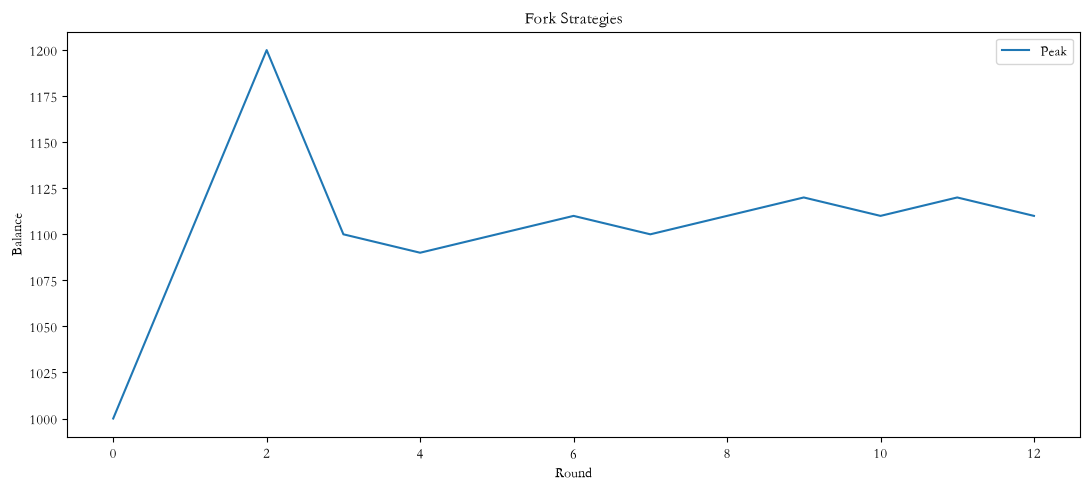

In [46]:
from visualize import Visualizer
from strategy import Peak

game = Coin()
vault = Vault(1000.0, 10.0)
session = Session(game, vault)

# 当余额处于历史最高点时重仓下注 100, 否则保守平注 10
strategy = Peak(Flat(100.0)).apply(Flat(10.0))
for _ in range(12):
    session.run(strategy)

viz = Visualizer("Fork Strategies", "Round", "Balance")


def money(session: Session):
    return [n.vault.money for n in session.data.nodes]


viz.add(money(session), "Peak").show()

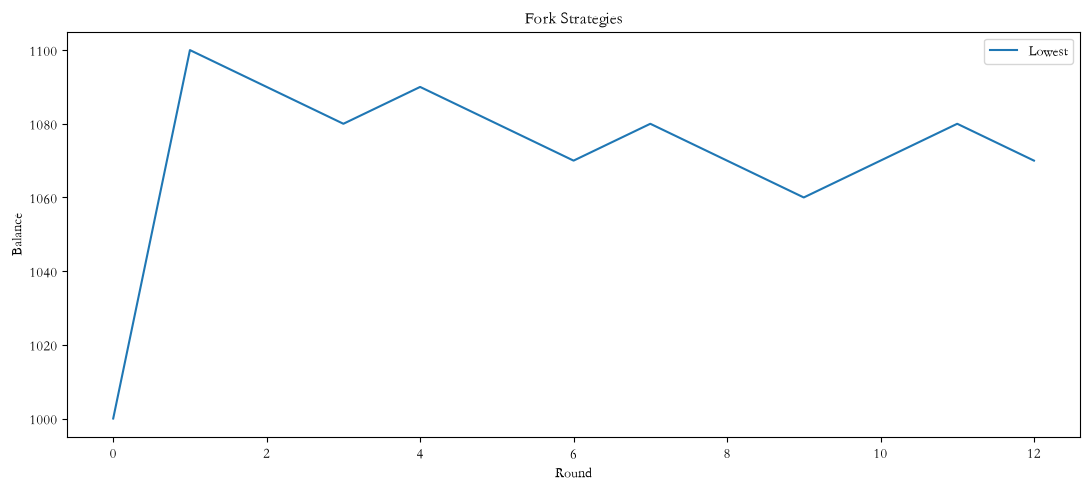

In [47]:
from strategy import Lowest

# 反过来: 处于历史最低点时重仓博反弹
vault = Vault(1000.0, 10.0)
session = Session(game, vault)

strategy = Lowest(Flat(100.0)).apply(Flat(10.0))
for _ in range(12):
    session.run(strategy)

viz.clear()
viz.add(money(session), "Lowest").show()

##### 3.4.2 锁定策略 (Lock)

`Lock` 会先**试算**其内部策略的下注额并存储相应额度, 后续依赖余额的计算会扣掉存储部分

它的条件永远不成立, 管道必定触发


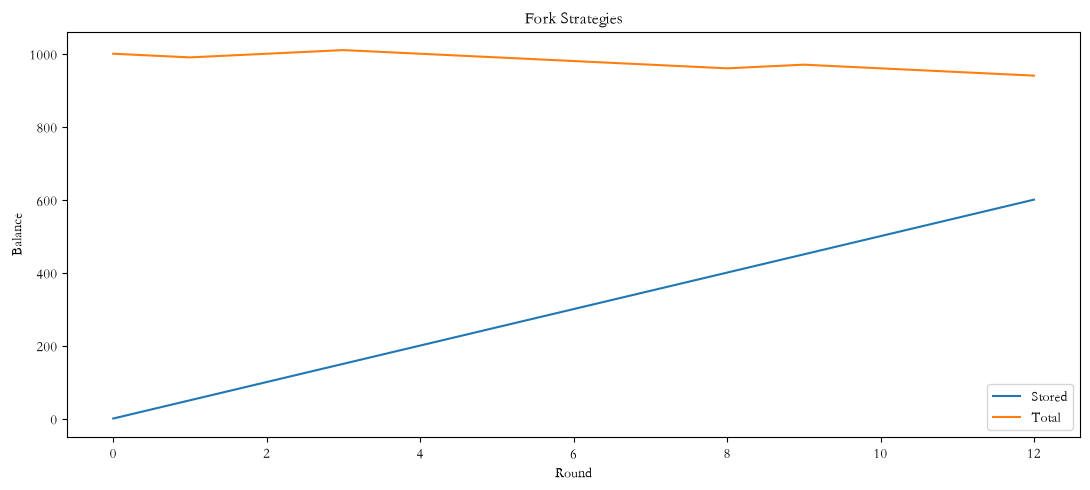

In [48]:
from strategy import Lock

vault = Vault(1000.0, 10.0)
session = Session(game, vault)
# 每局先锁定 50, 再平注 10
strategy = Lock(Flat(50.0)).apply(Flat(10.0))

for _ in range(12):
    session.run(strategy)


def total(session: Session):
    return [node.vault.total for node in session.data.nodes]


def stored(session: Session):
    return [node.vault.stored for node in session.data.nodes]


viz.clear()
viz.add(stored(session), "Stored").add(total(session), "Total").show()

#### 3.5 渐进式策略 (Progressive)

`Progressive` 是一族**根据历史输赢动态调整下注额**的策略

下面用确定性的 `SimpleGame` 把每种策略的下注额变化摆出来看清楚

In [49]:
from strategy import Martingale, DAlembert, Fibonacci, Labouchere, Stepping


def execute(strategy, seq):
    g = SimpleGame(seq)
    v = Vault(1000.0, 10.0)
    s = Session(g, v)
    for _ in range(len(seq)):
        s.run(strategy)
    return s


viz = Visualizer("Progressive", "Round", "Balance")

马丁格尔: 输了翻倍, 赢了复位

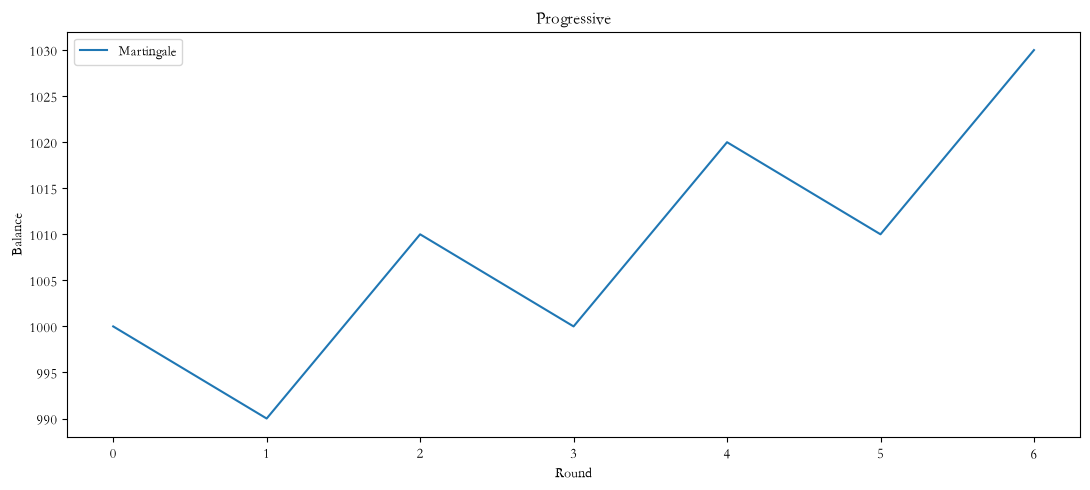

In [50]:
session = execute(Martingale(), [False, True, False, True, False, True])
viz.add(money(session), "Martingale").show()

达朗贝尔: 输了 +1 单位, 赢了 -1 单位

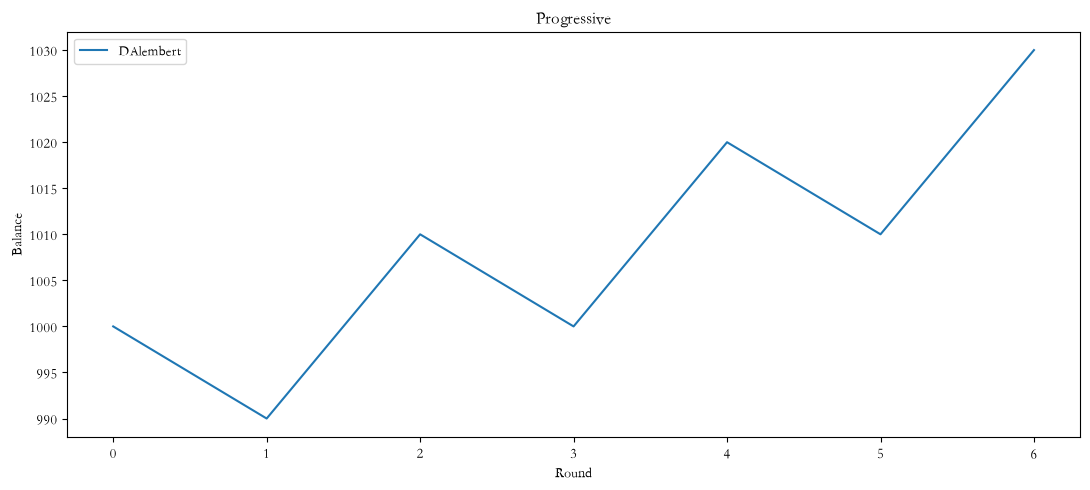

In [51]:
session = execute(DAlembert(), [False, True, False, True, False, True])
viz.clear()
viz.add(money(session), "DAlembert").show()

斐波那契: 赢了沿斐波那契数列前进, 输了回退两步

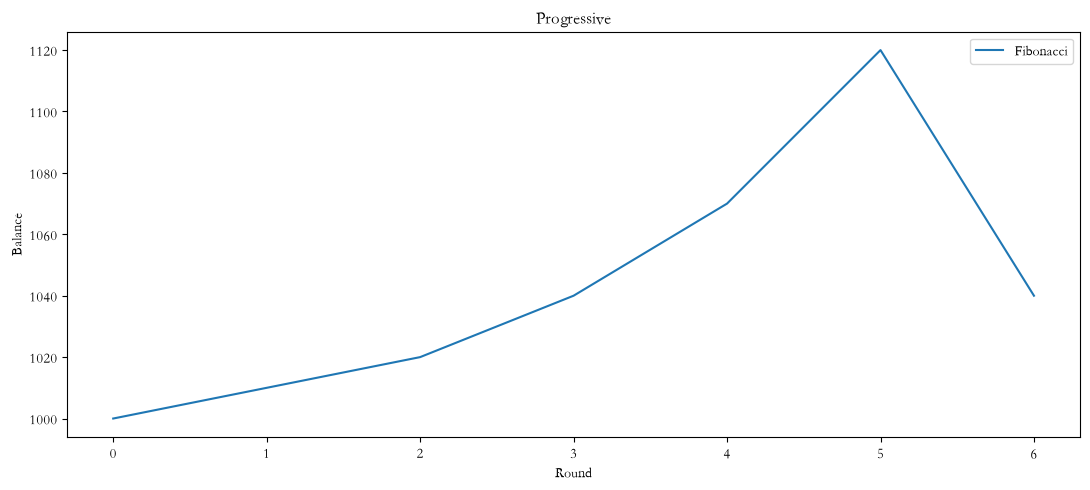

In [52]:
session = execute(Fibonacci(), [True, True, True, True, True, False])
viz.clear()
viz.add(money(session), "Fibonacci").show()

阶梯策略: 连赢时按档位递增, 一输即复位

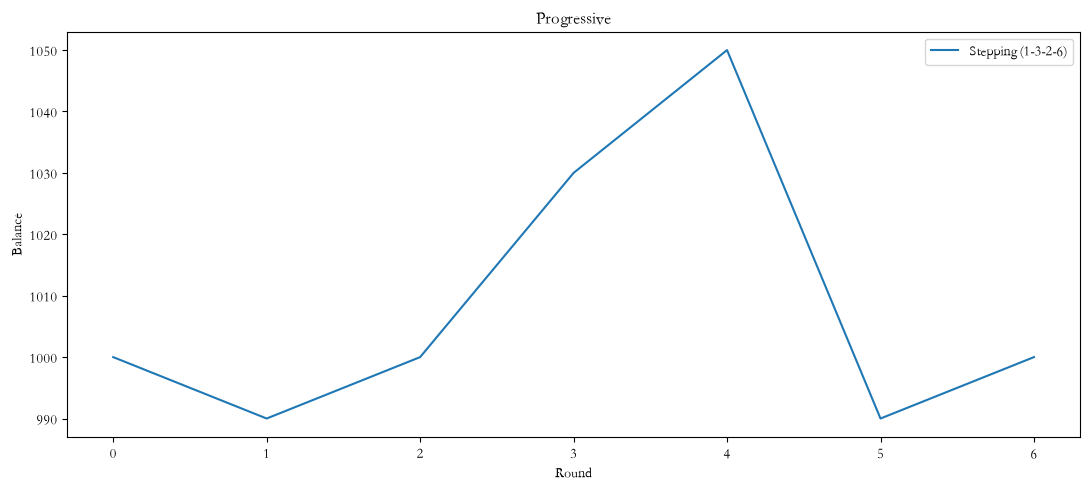

In [53]:
# 经典的 1-3-2-6 系统
session = execute(Stepping([1, 3, 2, 6]), [False, True, True, True, False, True])
viz.clear()
viz.add(money(session), "Stepping (1-3-2-6)").show()

拉博契尔: 下注管道首尾之和, 赢了划掉下注项, 输了把下注项之和加入管道末尾

只有一项时直接根据该项下注, 管道为空时执行内部策略

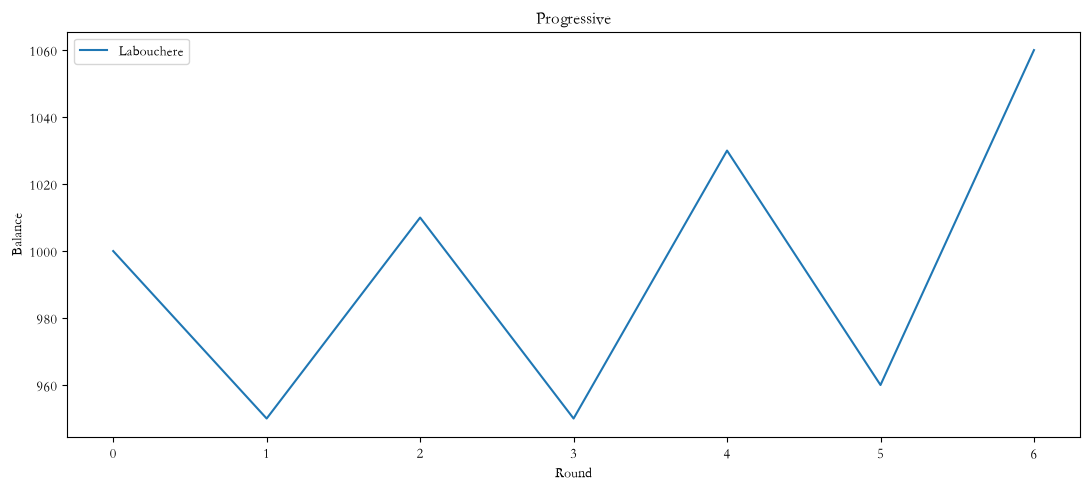

In [54]:
session = execute(
    Labouchere(Flat(10.0))
    .apply(Flat(10.0))
    .apply(Flat(20.0))
    .apply(Flat(30.0))
    .apply(Flat(40.0)),
    [False, True, False, True, False, True],
)
viz.clear()
viz.add(money(session), "Labouchere").show()

### 4. 大横评

说了这么多, 你也许坐不住了

让我们跑跑实际数据, 来个大横评

#### 4.1 骰子游戏

扔若干个若干面的骰子, 骰子点数全相同则失败, 否则若总和大于期望则获胜, 按倍率返还

In [55]:
from utils import positive, same
from functools import cached_property

class Dice(Game):
    def __init__(self, dice: list[int], amount: int, rate: float):
        self.dice = dice
        if not positive(self.length, amount, rate):
            raise ValueError
        self.amount = amount
        self.rate = rate

    def once(self, bet: float) -> float | None:
        if self.random():
            return bet * self.rate

    def random(self) -> bool:
        result = [self.roll() for _ in range(self.amount)]
        if same(result):
            return False
        total = sum(result)
        return total >= self.mean

    def roll(self):
        return random.choice(self.dice)

    @property
    def length(self):
        return len(self.dice)

    @cached_property
    def mean(self):
        return (sum(self.dice) * self.amount + self.length - 1) // self.length

以最经典的 Sic Bo 为例, 测测预期

In [56]:
dice = Dice([i for i in range(1, 7)], 3, 2.0)

win = 0
size = 100000
for _ in range(size):
    win += dice.random()

print(win / size)

0.48405


胜率约为 48.7% , 庄家占优

#### 4.2 策略混战

Test Conditions: 100 rounds, win rate 56%

Start Battle...

Flat (Baseline 10.0)      | Final:   1120.0 | Peak:   1140.0 | Drawdown:  12.3% | [WIN]
Martingale                | Final:   1120.0 | Peak:   1140.0 | Drawdown:  12.3% | [WIN]
DAlembert                 | Final:   1120.0 | Peak:   1140.0 | Drawdown:  12.3% | [WIN]
Fibonacci                 | Final:   1120.0 | Peak:   1140.0 | Drawdown:  12.3% | [WIN]
Labouchere                | Final:   1230.0 | Peak:   1250.0 | Drawdown:  20.0% | [WIN]
1326 System               | Final:   1270.0 | Peak:   1320.0 | Drawdown:  24.2% | [WIN]
10%                       | [FAIL] 
Peak -> Martingale, else 5.0 | Final:   1095.0 | Peak:   1110.0 | Drawdown:   9.9% | [WIN]
Max (Martingale, DAlembert(2.0), Fibonacci) | Final:   1610.0 | Peak:   2480.0 | Drawdown:  59.7% | [WIN]
Average (Martingale, DAlembert(2.0), Fibonacci) | Final:   2140.0 | Peak:   2870.0 | Drawdown:  65.2% | [WIN]


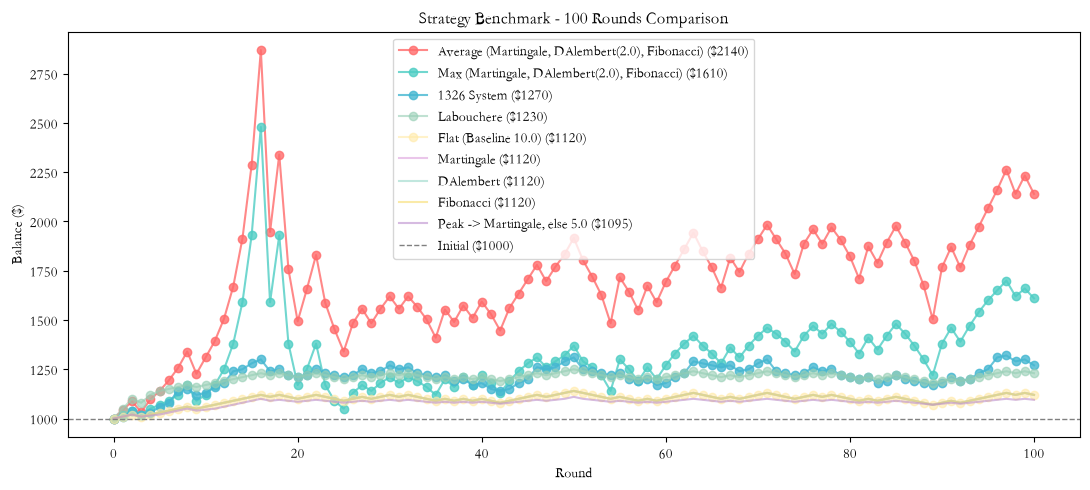

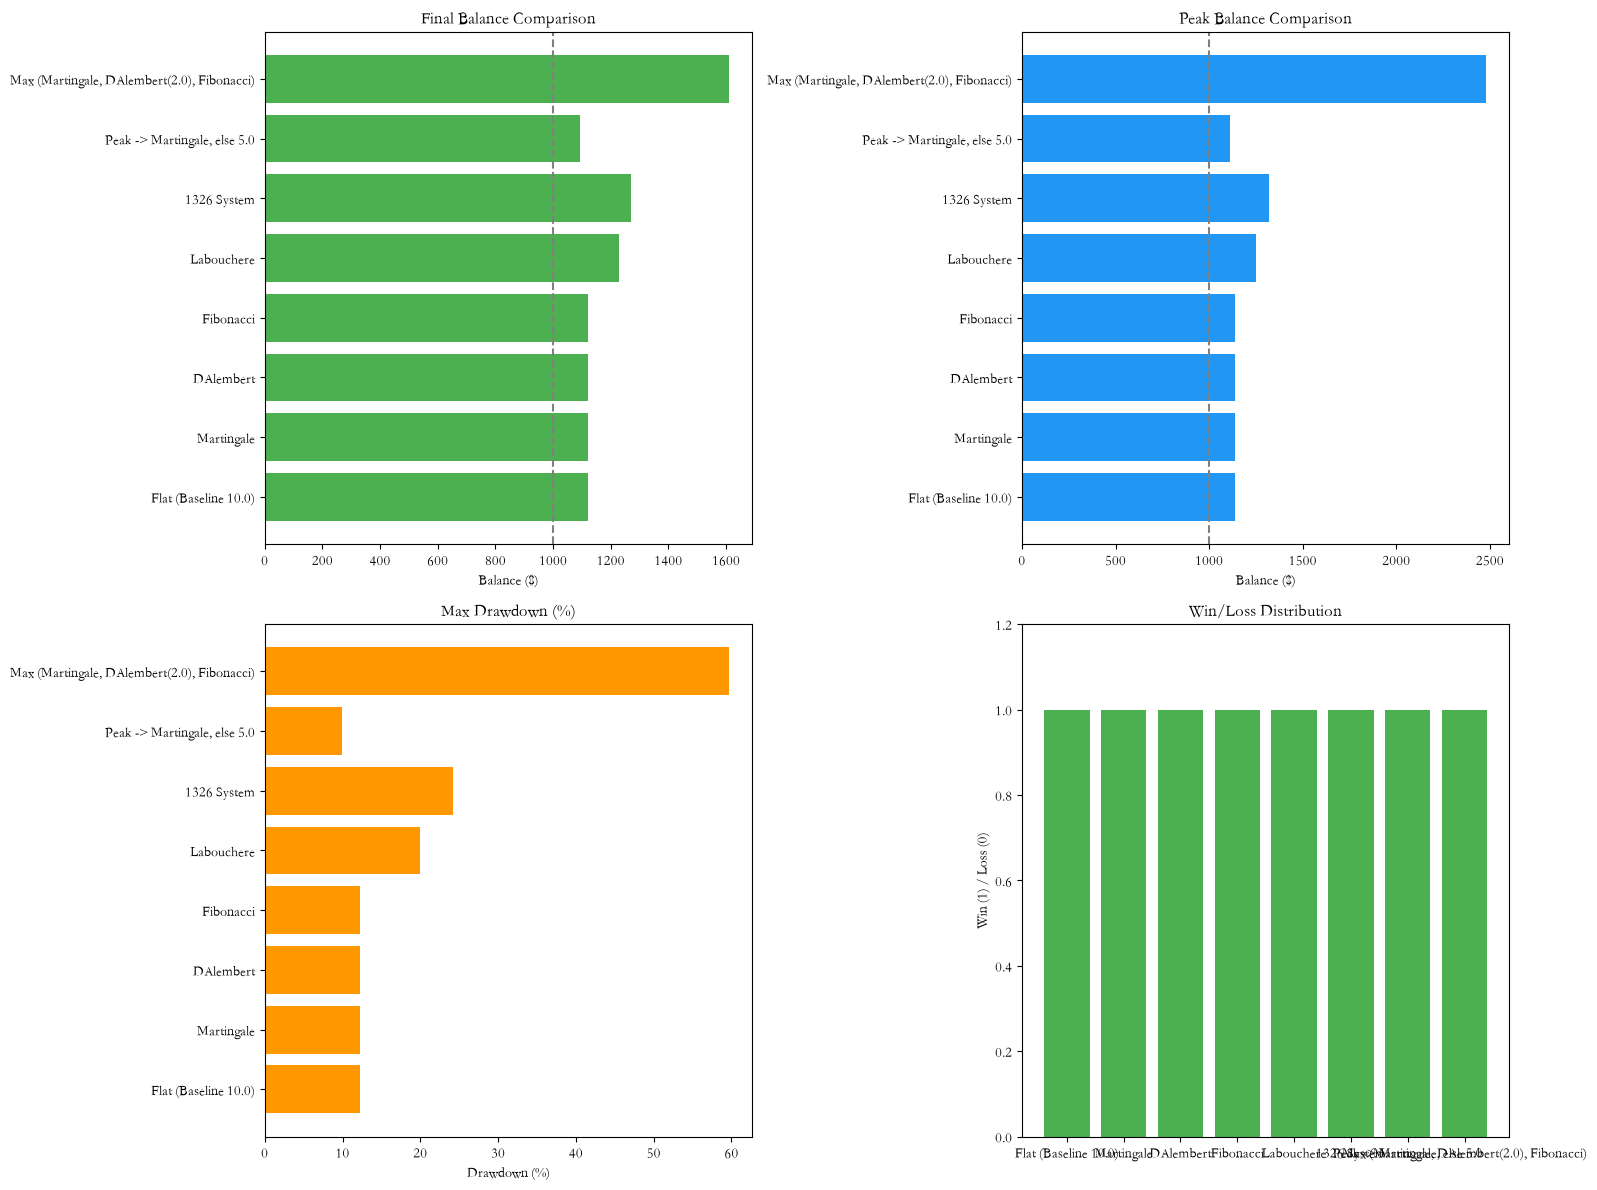


Benchmark Summary Report

Winning Strategies (9/10):
  1. Average (Martingale, DAlembert(2.0), Fibonacci) + 114.0%  (Peak: $2870, Drawdown: 65.2%)
  2. Max (Martingale, DAlembert(2.0), Fibonacci) +  61.0%  (Peak: $2480, Drawdown: 59.7%)
  3. 1326 System             +  27.0%  (Peak: $1320, Drawdown: 24.2%)
  4. Labouchere              +  23.0%  (Peak: $1250, Drawdown: 20.0%)
  5. Flat (Baseline 10.0)    +  12.0%  (Peak: $1140, Drawdown: 12.3%)
  6. Martingale              +  12.0%  (Peak: $1140, Drawdown: 12.3%)
  7. DAlembert               +  12.0%  (Peak: $1140, Drawdown: 12.3%)
  8. Fibonacci               +  12.0%  (Peak: $1140, Drawdown: 12.3%)
  9. Peak -> Martingale, else 5.0 +   9.5%  (Peak: $1110, Drawdown: 9.9%)

Losing Strategies (0/10):

Champion: Average (Martingale, DAlembert(2.0), Fibonacci)
   Final Balance: $2140.00
   Return Rate:   +114.00%
   Max Drawdown: 65.2%

Conclusion:
   Most strategies achieved positive returns in this scenario
   Recommend combining with ri

In [ ]:
# 固定随机种子保证可重复性
random.seed(42)

# 生成 100 轮随机结果 (模拟真实博弈)
results_100 = [random.choice([True, False]) for _ in range(100)]
wins = sum(results_100)
print(f"Test Conditions: 100 rounds, win rate {wins}%")

# 定义所有待测策略
strategies = {
    "Flat (Baseline 10.0)": Flat(10.0),
    "Martingale": Flat(10.0).apply(Martingale()),
    "DAlembert": Flat(10.0).apply(DAlembert()),
    "Fibonacci": Flat(10.0).apply(Fibonacci()),
    "Labouchere": Labouchere(Flat(10.0))
        .apply(Flat(10.0))
        .apply(Flat(20.0))
        .apply(Flat(30.0))
        .apply(Flat(40.0)),
    "1326 System": Stepping([1, 3, 2, 6]),
    "10%": Allin().apply(Ratio(0.1)),
    "Peak -> Martingale, else 5.0": Peak(
        Flat(10.0).apply(Martingale())
    ).apply(Flat(5.0)),
    "Max (Martingale, DAlembert(2.0), Fibonacci)": Max()
        .apply(Martingale())
        .apply(DAlembert(unit=2.0))
        .apply(Fibonacci()),
    "Average (Martingale, DAlembert(2.0), Fibonacci)": Sum()
        .apply(Martingale())
        .apply(DAlembert(unit=2.0))
        .apply(Fibonacci())
        .apply(Ratio(1/3))
}

print("\nStart Battle...\n")
benchmark_results = {}

for name, strategy in strategies.items():
    try:
        session = execute(strategy, results_100)
        balances = money(session)
        final_balance = balances[-1]
        peak_balance = max(balances)
        min_balance = min(balances)
        drawdown = (peak_balance - min_balance) / peak_balance * 100 if peak_balance > 0 else 0

        benchmark_results[name] = {
            'balances': balances,
            'final': final_balance,
            'peak': peak_balance,
            'min': min_balance,
            'drawdown': drawdown,
            'success': final_balance > 1000
        }

        status = "[WIN]" if final_balance > 1000 else "[LOSS]"
        print(f"{name:<25} | Final: {final_balance:>8.1f} | Peak: {peak_balance:>8.1f} | Drawdown: {drawdown:>5.1f}% | {status}")
    except Exception as e:
        print(f"{name:<25} | [FAIL] {str(e)[:50]}")
        benchmark_results[name] = None

# Generate comparison chart
viz_benchmark = Visualizer(
    "Strategy Benchmark - 100 Rounds Comparison",
    "Round",
    "Balance ($)"
)

# Sort by final balance (descending)
sorted_strategies = sorted(
    [(name, data) for name, data in benchmark_results.items() if data],
    key=lambda x: x[1]['final'],
    reverse=True
)

colors = [
    "#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4",
    "#FFEAA7", "#DDA0DD", "#98D8C8", "#F7DC6F",
    "#BB8FCE", "#85C1E9", "#F8B500"
]

for i, (name, data) in enumerate(sorted_strategies):
    color = colors[i % len(colors)]
    marker = 'o' if data['success'] else 'x'
    viz_benchmark.add(
        data['balances'],
        f"{name} (${data['final']:.0f})",
        color=color,
        marker=marker if i < 5 else None,
        alpha=0.8 if i < 3 else 0.6
    )

viz_benchmark.hline(1000, "Initial ($1000)", color="gray", linestyle="--").show()

# Generate statistics charts
import matplotlib.pyplot as plt

successful = {n: d for n, d in benchmark_results.items() if d}

if successful:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    names = list(successful.keys())[:8]
    finals = [successful[n]['final'] for n in names]
    peaks = [successful[n]['peak'] for n in names]
    drawdowns = [successful[n]['drawdown'] for n in names]
    success_rate = [1 if successful[n]['success'] else 0 for n in names]

    # Subplot 1: Final balance
    axes[0, 0].barh(names, finals, color=['#4CAF50' if f > 1000 else '#F44336' for f in finals])
    axes[0, 0].axvline(x=1000, color='gray', linestyle='--', label='Initial')
    axes[0, 0].set_title('Final Balance Comparison')
    axes[0, 0].set_xlabel('Balance ($)')

    # Subplot 2: Peak balance
    axes[0, 1].barh(names, peaks, color='#2196F3')
    axes[0, 1].axvline(x=1000, color='gray', linestyle='--', label='Initial')
    axes[0, 1].set_title('Peak Balance Comparison')
    axes[0, 1].set_xlabel('Balance ($)')

    # Subplot 3: Max drawdown
    axes[1, 0].barh(names, drawdowns, color='#FF9800')
    axes[1, 0].set_title('Max Drawdown (%)')
    axes[1, 0].set_xlabel('Drawdown (%)')

    # Subplot 4: Win/Loss distribution
    axes[1, 1].bar(names, success_rate, color=['#4CAF50' if s else '#F44336' for s in success_rate])
    axes[1, 1].set_title('Win/Loss Distribution')
    axes[1, 1].set_ylabel('Win (1) / Loss (0)')
    axes[1, 1].set_ylim(0, 1.2)

    plt.tight_layout()
    plt.show()
else:
    print("Warning: All strategies failed, cannot generate statistics")

# Print summary report
print("\n" + "="*70)
print("Benchmark Summary Report")
print("="*70)

winners = [(n, d) for n, d in benchmark_results.items() if d and d['success']]
losers = [(n, d) for n, d in benchmark_results.items() if d and not d['success']]

print(f"\nWinning Strategies ({len(winners)}/{len(benchmark_results)}):")
for i, (name, data) in enumerate(sorted(winners, key=lambda x: x[1]['final'], reverse=True), 1):
    profit_pct = (data['final'] - 1000) / 1000 * 100
    print(f"  {i}. {name:<23} +{profit_pct:>6.1f}%  (Peak: ${data['peak']:.0f}, Drawdown: {data['drawdown']:.1f}%)")

print(f"\nLosing Strategies ({len(losers)}/{len(benchmark_results)}):")
for i, (name, data) in enumerate(sorted(losers, key=lambda x: x[1]['final']), 1):
    loss_pct = (data['final'] - 1000) / 1000 * 100
    print(f"  {i}. {name:<23} {loss_pct:>6.1f}%  (Min: ${data['min']:.0f}, Drawdown: {data['drawdown']:.1f}%)")

if winners:
    best_strategy = max(winners, key=lambda x: x[1]['final'])
    print(f"\nChampion: {best_strategy[0]}")
    print(f"   Final Balance: ${best_strategy[1]['final']:.2f}")
    print(f"   Return Rate:   {(best_strategy[1]['final']-1000)/1000*100:+.2f}%")
    print(f"   Max Drawdown: {best_strategy[1]['drawdown']:.1f}%")

print("\n" + "="*70)
print("Conclusion:")
if len(winners) > len(losers):
    print("   Most strategies achieved positive returns in this scenario")
else:
    print("   House edge is significant, use aggressive strategies with caution")
print("   Recommend combining with risk control strategies (Peak/Lock/Ratio)")
print("="*70)